# Notebook 4 of 4 — Stage 7: Model Optimization and Final Model Selection

## 1. Introduction

Stage 6 (`03_ModelDevelopment.ipynb`) evaluated four baseline machine learning algorithms: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Random Forest.

The baseline experiments showed that the models have different strengths and weaknesses. Random Forest demonstrated the strongest overall performance, the Decision Tree achieved relatively strong recall but clearly overfitted, Logistic Regression underfitted, and KNN was the weakest model on every metric.

The purpose of Stage 7 is to investigate whether model performance can be improved through hyperparameter tuning and other modelling choices.

Hyperparameter optimization is performed using the training data with stratified cross-validation. The test dataset is kept separate from all tuning and selection decisions so that it provides an independent evaluation of the final model.

The main objectives of this stage are:

- Tune suitable machine learning models (Decision Tree, Random Forest, Logistic Regression).
- Use an appropriate hyperparameter search strategy (Grid Search or Randomized Search).
- Handle the moderate class imbalance by tuning `class_weight` as a hyperparameter.
- Compare tuned models with their baseline versions.
- Check, with evidence, whether KNN is worth taking forward.
- Investigate whether feature selection improves performance.
- Test the robustness of the model to the engagement-survey features flagged as a possible leakage risk in the EDA.
- Select and justify the final employee attrition prediction model.

## 2. Environment Setup and Library Imports

The required Python libraries are imported for data handling, model development, hyperparameter optimization, cross-validation, evaluation, and visualization.

The same random state used during model development is maintained where applicable to improve reproducibility.

In [1]:
# Data handling
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model selection, optimization and feature selection
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Saving the final model
import joblib

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Processed Training and Testing Data

The processed datasets created during the preprocessing and feature engineering stage are loaded directly for model optimization.

Two versions of the feature datasets are available:

- **Scaled data** – suitable for models that are sensitive to feature magnitude, such as Logistic Regression.
- **Unscaled data** – suitable for tree-based models such as Decision Tree and Random Forest.

The same train-test split created during preprocessing is retained to ensure consistency with the baseline experiments performed in Stage 6.

In [2]:
# Path to processed datasets
DATA_PATH = "../processed_data/"

# Load unscaled datasets
X_train_unscaled = pd.read_csv(DATA_PATH + "X_train_unscaled.csv")
X_test_unscaled = pd.read_csv(DATA_PATH + "X_test_unscaled.csv")

# Load scaled datasets
X_train_scaled = pd.read_csv(DATA_PATH + "X_train_scaled.csv")
X_test_scaled = pd.read_csv(DATA_PATH + "X_test_scaled.csv")

# Load target datasets
y_train = pd.read_csv(
    DATA_PATH + "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH + "y_test.csv"
).squeeze("columns")

print("Datasets loaded successfully.\n")

print("Dataset Shapes:")
print("X_train_unscaled :", X_train_unscaled.shape)
print("X_test_unscaled  :", X_test_unscaled.shape)
print("X_train_scaled   :", X_train_scaled.shape)
print("X_test_scaled    :", X_test_scaled.shape)
print("y_train          :", y_train.shape)
print("y_test           :", y_test.shape)

Datasets loaded successfully.

Dataset Shapes:
X_train_unscaled : (4000, 41)
X_test_unscaled  : (1000, 41)
X_train_scaled   : (4000, 41)
X_test_scaled    : (1000, 41)
y_train          : (4000,)
y_test           : (1000,)


### 3.1 Confirm Numerical Feature Representation

The preprocessing notebook converts the one-hot encoded columns to `0`/`1` integers before saving, so every feature should already be numeric. This is checked before modelling.

In [3]:
for name, dataset in {
    "X_train_unscaled": X_train_unscaled,
    "X_test_unscaled": X_test_unscaled,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled
}.items():
    non_numeric = dataset.select_dtypes(exclude=np.number).columns.tolist()
    assert not non_numeric, f"{name} has non-numeric columns: {non_numeric}"

print("All feature columns are numeric.")

All feature columns are numeric.


## 4. Optimization and Validation Strategy

Stratified 5-fold cross-validation is used during hyperparameter optimization.

Stratification preserves approximately the same proportion of attrition and non-attrition cases in each validation fold. This is appropriate because the target variable is not perfectly balanced.

Hyperparameters are selected using only the training dataset. The test dataset is not used during hyperparameter selection and is reserved for later evaluation of the optimized models.

Multiple performance metrics will continue to be considered, including accuracy, precision, recall, F1-score and ROC-AUC.

In [4]:
# Stratified 5-fold cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics used for model evaluation
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


def cv_means(cv_results):
    """Mean cross-validation score for each metric."""
    return {
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean()
    }


print("Stratified 5-fold cross-validation configured.")

Stratified 5-fold cross-validation configured.


### 4.1 Baseline Reference Results

The four baseline models from Stage 6 are re-evaluated here with exactly the same settings and the same cross-validation folds. This gives the reference results that each tuned model is compared against, calculated in this notebook rather than copied by hand from Stage 6.

The mean **training** F1-score is also recorded, so that the overfitting gap of each baseline can be compared with its tuned version.

In [5]:
baseline_models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_scaled),
    "KNN": (KNeighborsClassifier(), X_train_scaled),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), X_train_unscaled),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), X_train_unscaled)
}

baseline_cv = {}

for name, (model, X) in baseline_models.items():
    baseline_cv[name] = cross_validate(
        model,
        X,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1
    )

baseline_table = pd.DataFrame({
    name: {**cv_means(results), "Train F1": results["train_f1"].mean()}
    for name, results in baseline_cv.items()
}).T

print("Baseline models - 5-Fold Cross-Validation Results (same as Stage 6)")
display(baseline_table.round(4))

Baseline models - 5-Fold Cross-Validation Results (same as Stage 6)


,Accuracy,Precision,Recall,F1,ROC-AUC,Train F1
Logistic Regression,0.6998,0.6421,0.4319,0.5161,0.7032,0.5255
KNN,0.6440,0.5306,0.3571,0.4266,0.6149,0.6344
Decision Tree,0.6675,0.5510,0.5654,0.5577,0.6466,1.0000
Random Forest,0.7962,0.8167,0.5822,0.6790,0.7612,1.0000


## 5. Decision Tree Hyperparameter Optimization

The baseline Decision Tree showed relatively strong recall for identifying employees who left the company, but its precision and overall discrimination were lower than Random Forest.

An unrestricted Decision Tree can grow very deep and learn patterns that are specific to the training data. This may increase the risk of overfitting.

Hyperparameter tuning is therefore performed to control the complexity of the tree and investigate whether its generalization performance can be improved.

Grid Search with stratified 5-fold cross-validation is used because the selected Decision Tree hyperparameters form a manageable search space. The search evaluates different combinations systematically using only the training data.

F1-score is used as the primary optimization metric because employee attrition prediction requires consideration of both precision and recall.

### 5.1 Hyperparameter Search Space

The following Decision Tree hyperparameters are investigated:

- `criterion` – the measure used to evaluate feature splits (Gini impurity or entropy / information gain).
- `max_depth` – the maximum depth of the tree. Smaller values give a simpler tree that is less likely to overfit.
- `min_samples_split` – the minimum number of observations required to split a node.
- `min_samples_leaf` – the minimum number of observations allowed in a leaf node.
- `class_weight` – `None` treats both classes equally; `'balanced'` gives the minority class (employees who left) more weight in proportion to how rare it is. This is how the moderate class imbalance (62.9% / 37.1%) is handled.

Several values are evaluated for each parameter to investigate the balance between model complexity and generalization.

In [6]:
# Decision Tree hyperparameter search space
decision_tree_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

# Calculate number of combinations
total_combinations = int(np.prod([len(v) for v in decision_tree_param_grid.values()]))

print("Total hyperparameter combinations:", total_combinations)
print("Total fits with 5-fold CV:", total_combinations * 5)

Total hyperparameter combinations: 240
Total fits with 5-fold CV: 1200


### 5.2 Grid Search with Cross-Validation

`GridSearchCV` is used to systematically evaluate every specified Decision Tree hyperparameter combination.

Each configuration is evaluated using stratified 5-fold cross-validation on the training dataset. F1-score is used as the primary optimization objective.

The test dataset is not involved in this search.

In [7]:
# Create Decision Tree model
dt_for_tuning = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

# Configure Grid Search
decision_tree_grid_search = GridSearchCV(
    estimator=dt_for_tuning,
    param_grid=decision_tree_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Run hyperparameter search using training data only
decision_tree_grid_search.fit(
    X_train_unscaled,
    y_train
)

print("\nDecision Tree tuning completed.")

print("\nBest Hyperparameters:")
print(decision_tree_grid_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(decision_tree_grid_search.best_score_, 4)
)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits



Decision Tree tuning completed.

Best Hyperparameters:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}

Best Cross-Validation F1: 0.6874


### 5.3 Decision Tree Tuning Results

Grid Search evaluated 240 Decision Tree hyperparameter combinations using stratified 5-fold cross-validation, resulting in 1,200 cross-validation fits.

The best configuration was:

- **Criterion:** Entropy
- **Maximum depth:** 5
- **Minimum samples split:** 10
- **Minimum samples leaf:** 1
- **Class weight:** None

The optimized configuration achieved a best cross-validation F1-score of **0.6874**, compared with **0.5577** for the baseline Decision Tree.

The most important change is the **maximum depth of 5**. The baseline tree was unrestricted and grew until it memorised the training data (training F1 = 1.000, Section 4.1). Limiting the depth forces the tree to learn only the strongest, most general rules. `class_weight='balanced'` did not give a higher F1 than the unweighted tree, so the search kept `None`.

The best cross-validation F1-score alone is not sufficient for final model selection. The tuned model is also evaluated across the other performance metrics and later compared with the other optimized models.

### 5.4 Training and Validation Performance of the Selected Decision Tree

To further investigate the effect of hyperparameter tuning, the mean training and validation F1-scores of the best Decision Tree configuration are compared.

A very large difference between training and validation performance can indicate overfitting, where the model performs substantially better on training data than on unseen validation data.

In [8]:
# Get the index of the best Decision Tree configuration
best_dt_index = decision_tree_grid_search.best_index_

# Extract training and validation F1 for the best configuration
best_dt_train_f1 = decision_tree_grid_search.cv_results_[
    "mean_train_score"
][best_dt_index]

best_dt_validation_f1 = decision_tree_grid_search.cv_results_[
    "mean_test_score"
][best_dt_index]

dt_f1_gap = best_dt_train_f1 - best_dt_validation_f1

print("Selected Decision Tree - Training vs Validation\n")
print(f"Mean Training F1   : {best_dt_train_f1:.4f}")
print(f"Mean Validation F1 : {best_dt_validation_f1:.4f}")
print(f"Difference         : {dt_f1_gap:.4f}")

Selected Decision Tree - Training vs Validation

Mean Training F1   : 0.7007
Mean Validation F1 : 0.6874
Difference         : 0.0133


### 5.5 Optimized Decision Tree Cross-Validation Evaluation

Although F1-score was used as the primary optimization objective, the selected Decision Tree is also evaluated using accuracy, precision, recall and ROC-AUC.

This provides a more complete assessment of whether the improvement in F1-score is accompanied by reasonable performance across the other evaluation measures.

In [9]:
# Retrieve the best tuned Decision Tree
tuned_decision_tree = decision_tree_grid_search.best_estimator_

# Evaluate tuned model using the same cross-validation strategy
tuned_dt_cv_results = cross_validate(
    tuned_decision_tree,
    X_train_unscaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("Tuned Decision Tree - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = tuned_dt_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Tuned Decision Tree - 5-Fold Cross-Validation Results

Accuracy  : 0.8010 ± 0.0099
Precision : 0.8228 ± 0.0108
Recall    : 0.5909 ± 0.0310
F1        : 0.6874 ± 0.0218
Roc_auc   : 0.7552 ± 0.0193


### 5.6 Decision Tree Optimization Observation

Hyperparameter tuning substantially improved the Decision Tree's cross-validation performance.

The baseline Decision Tree achieved an F1-score of approximately 0.558, while the optimized Decision Tree achieved approximately 0.687. Accuracy increased from approximately 0.668 to 0.801, precision from 0.551 to 0.823, recall from 0.565 to 0.591, and ROC-AUC from 0.647 to 0.755.

The mean training F1-score was 0.7007 and the mean validation F1-score was 0.6874, a difference of only 0.0133. For the baseline tree the same gap was 0.442 (training F1 1.000 vs validation F1 0.558). Tuning therefore removed the severe overfitting identified in Stage 6.

Overall, controlling the complexity of the Decision Tree was the key to improving it: a shallow tree of depth 5 generalises far better than an unrestricted one on this dataset.

### 5.7 Baseline vs Optimized Decision Tree

The baseline and optimized Decision Tree models are compared using the same cross-validation metrics. This comparison demonstrates the effect of hyperparameter tuning on model performance.

,Baseline Decision Tree,Tuned Decision Tree
Accuracy,0.6675,0.8010
Precision,0.5510,0.8228
Recall,0.5654,0.5909
F1,0.5577,0.6874
ROC-AUC,0.6466,0.7552


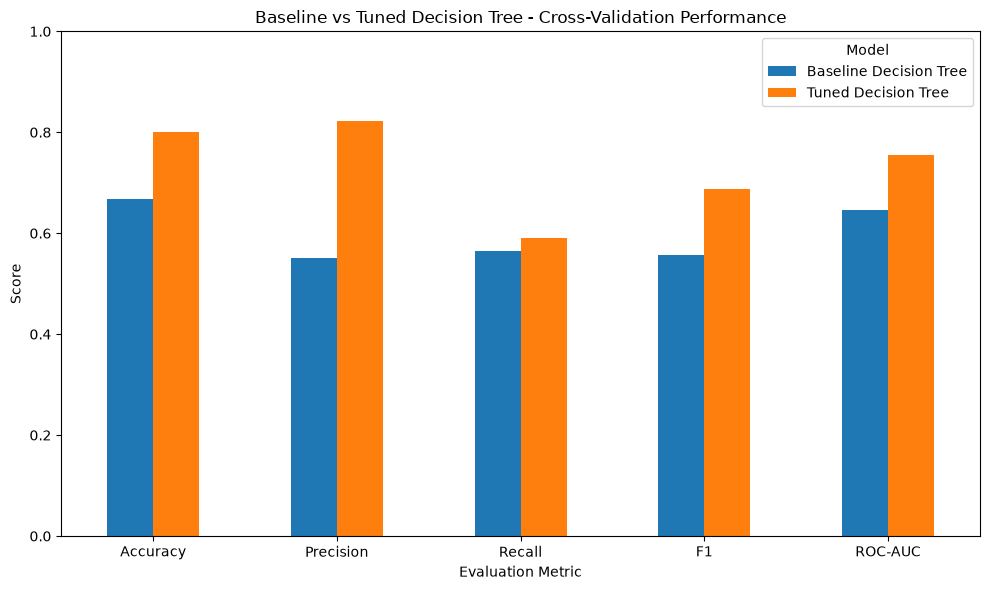

In [10]:
# Baseline Decision Tree cross-validation results (Section 4.1)
baseline_dt_metrics = cv_means(baseline_cv["Decision Tree"])

# Tuned Decision Tree results
tuned_dt_metrics = cv_means(tuned_dt_cv_results)

# Create comparison DataFrame
dt_comparison = pd.DataFrame({
    "Baseline Decision Tree": baseline_dt_metrics,
    "Tuned Decision Tree": tuned_dt_metrics
})

display(dt_comparison.round(4))

# Plot comparison
ax = dt_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned Decision Tree - Cross-Validation Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 6. Random Forest Hyperparameter Optimization

Random Forest demonstrated the strongest overall performance among the baseline models in Stage 6. It achieved high accuracy, precision, F1-score and ROC-AUC while maintaining reasonable recall.

Random Forest combines predictions from multiple Decision Trees, which generally improves stability and reduces the risk of overfitting compared with a single unrestricted tree.

However, the performance of Random Forest depends on several hyperparameters controlling the number, complexity and diversity of trees. Therefore, hyperparameter optimization is performed to investigate whether its performance can be improved further.

Randomized Search with stratified 5-fold cross-validation is used because the Random Forest search space contains many possible hyperparameter combinations. F1-score is used as the primary optimization metric to balance precision and recall.

### 6.1 Random Forest Hyperparameter Search Space

The Random Forest optimization investigates hyperparameters that control the number of trees, individual tree complexity, feature sampling and class weighting.

The selected hyperparameters are:

- `n_estimators` – number of trees in the forest.
- `max_depth` – maximum depth of each tree.
- `min_samples_split` – minimum samples required to split a node.
- `min_samples_leaf` – minimum samples required in a leaf.
- `max_features` – number of features considered when identifying a split (`None` = all features).
- `class_weight` – `None` or `'balanced'` (gives more weight to employees who left, the minority class).

A randomized search is used instead of exhaustively evaluating every possible combination because the Random Forest search space is considerably larger than the Decision Tree search space.

In [11]:
random_forest_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

total_rf_combinations = int(np.prod([len(v) for v in random_forest_param_dist.values()]))

print("Total possible Random Forest combinations:", total_rf_combinations)
print("Combinations sampled by Randomized Search: 50")

Total possible Random Forest combinations: 1920
Combinations sampled by Randomized Search: 50


### 6.2 Randomized Search with Cross-Validation

`RandomizedSearchCV` is used to sample a fixed number of Random Forest hyperparameter combinations from the larger search space.

Each sampled configuration is evaluated using stratified 5-fold cross-validation on the training dataset. This provides a practical balance between computational cost and exploration of different model configurations.

The optimization objective remains F1-score so that both precision and recall are considered during hyperparameter selection.

In [12]:
# Create baseline Random Forest estimator for tuning
rf_for_tuning = RandomForestClassifier(
    random_state=RANDOM_STATE
)

# Configure Randomized Search
random_forest_random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=random_forest_param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Run optimization using training data only
random_forest_random_search.fit(
    X_train_unscaled,
    y_train
)

print("\nRandom Forest tuning completed.")

print("\nBest Hyperparameters:")
print(random_forest_random_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(random_forest_random_search.best_score_, 4)
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits



Random Forest tuning completed.

Best Hyperparameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 5, 'class_weight': 'balanced'}

Best Cross-Validation F1: 0.6934


### 6.3 Training and Validation Performance of the Selected Random Forest

The training and validation F1-scores of the selected Random Forest configuration are compared to check the generalization behaviour of the optimized model.

In [13]:
# Get index of best Random Forest configuration
best_rf_index = random_forest_random_search.best_index_

# Training and validation F1
best_rf_train_f1 = random_forest_random_search.cv_results_[
    "mean_train_score"
][best_rf_index]

best_rf_validation_f1 = random_forest_random_search.cv_results_[
    "mean_test_score"
][best_rf_index]

rf_f1_gap = best_rf_train_f1 - best_rf_validation_f1

print("Selected Random Forest - Training vs Validation\n")
print(f"Mean Training F1   : {best_rf_train_f1:.4f}")
print(f"Mean Validation F1 : {best_rf_validation_f1:.4f}")
print(f"Difference         : {rf_f1_gap:.4f}")

# Baseline Random Forest for comparison (Section 4.1)
baseline_rf_train_f1 = baseline_cv["Random Forest"]["train_f1"].mean()
baseline_rf_validation_f1 = baseline_cv["Random Forest"]["test_f1"].mean()

print("\nBaseline Random Forest - Training vs Validation\n")
print(f"Mean Training F1   : {baseline_rf_train_f1:.4f}")
print(f"Mean Validation F1 : {baseline_rf_validation_f1:.4f}")
print(f"Difference         : {baseline_rf_train_f1 - baseline_rf_validation_f1:.4f}")

Selected Random Forest - Training vs Validation

Mean Training F1   : 0.7001
Mean Validation F1 : 0.6934
Difference         : 0.0067

Baseline Random Forest - Training vs Validation

Mean Training F1   : 1.0000
Mean Validation F1 : 0.6790
Difference         : 0.3210


### 6.4 Optimized Random Forest Cross-Validation Evaluation

The optimized Random Forest is evaluated using accuracy, precision, recall, F1-score and ROC-AUC with the same stratified 5-fold cross-validation strategy used for the baseline models.

In [14]:
# Best tuned Random Forest
tuned_random_forest = random_forest_random_search.best_estimator_

# Evaluate using 5-fold cross-validation
tuned_rf_cv_results = cross_validate(
    tuned_random_forest,
    X_train_unscaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("Tuned Random Forest - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = tuned_rf_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Tuned Random Forest - 5-Fold Cross-Validation Results

Accuracy  : 0.8038 ± 0.0113
Precision : 0.8235 ± 0.0139
Recall    : 0.5997 ± 0.0349
F1        : 0.6934 ± 0.0241
Roc_auc   : 0.7580 ± 0.0191


### 6.5 Baseline vs Optimized Random Forest

The cross-validation performance of the optimized Random Forest is compared with the baseline Random Forest to determine the effect of hyperparameter tuning.

,Baseline Random Forest,Tuned Random Forest
Accuracy,0.7962,0.8038
Precision,0.8167,0.8235
Recall,0.5822,0.5997
F1,0.6790,0.6934
ROC-AUC,0.7612,0.7580


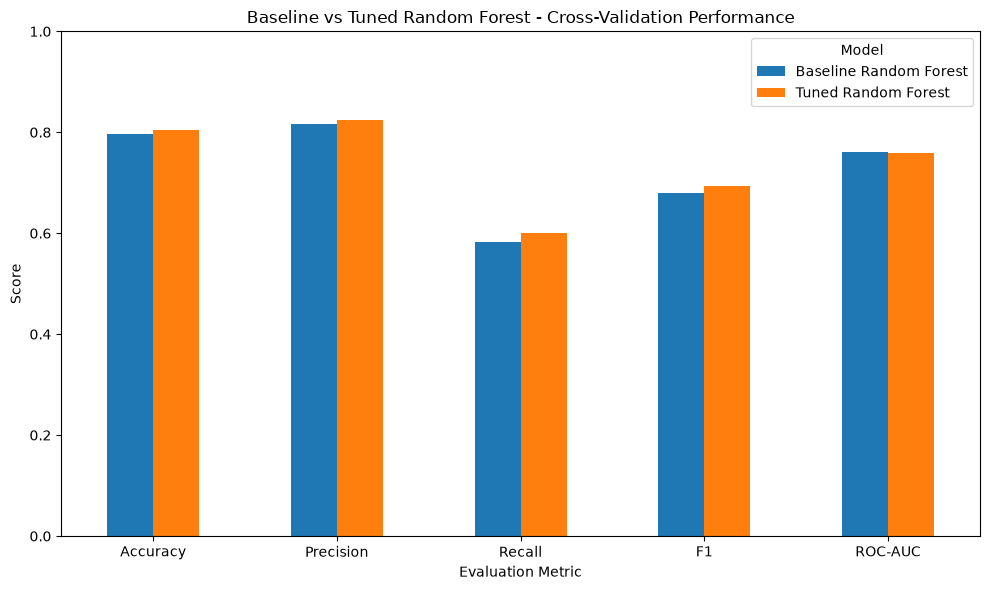

In [15]:
# Baseline Random Forest results (Section 4.1)
baseline_rf_metrics = cv_means(baseline_cv["Random Forest"])

# Tuned Random Forest results
tuned_rf_metrics = cv_means(tuned_rf_cv_results)

rf_comparison = pd.DataFrame({
    "Baseline Random Forest": baseline_rf_metrics,
    "Tuned Random Forest": tuned_rf_metrics
})

display(rf_comparison.round(4))

# Plot comparison
rf_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned Random Forest - Cross-Validation Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### 6.6 Random Forest Optimization Observation

The best Random Forest configuration found by Randomized Search was:

- **Number of trees (`n_estimators`):** 200
- **Maximum depth:** 5
- **Minimum samples split:** 2
- **Minimum samples leaf:** 8
- **Max features:** None (all features considered at each split)
- **Class weight:** balanced

Tuning increased the cross-validation F1-score from 0.679 to 0.693, accuracy from 0.796 to 0.804, precision from 0.817 to 0.824 and recall from 0.582 to 0.600. ROC-AUC was essentially unchanged (0.761 to 0.758, a difference much smaller than its fold standard deviation of about 0.019).

**The main benefit of tuning is a much less overfitted model.** The baseline Random Forest had a training F1 of 1.000 against a validation F1 of 0.679 (gap 0.321), because its trees were grown without any depth limit. The tuned forest has a training F1 of 0.700 against a validation F1 of 0.693 (gap only 0.007). Limiting depth to 5 and requiring at least 8 employees per leaf keeps every tree simple, while still giving slightly better validation performance.

Two other choices are worth explaining:

- **`max_features=None`:** the EDA showed that only about four of the 41 features carry real signal. With the default `'sqrt'` setting, each split sees only 6 randomly chosen features, and in about half of all splits (51.7%) none of the four key drivers would be available, forcing the tree to split on noise. Letting every split consider all features avoids this.
- **`class_weight='balanced'`:** gives more weight to employees who left (the minority class), which helps recall for the class that matters most to HR.

The F1 improvement is modest because the baseline Random Forest was already the strongest model; averaging many trees had already compensated for much of the individual trees' overfitting.

## 7. Logistic Regression Hyperparameter Optimization

Logistic Regression is optimized to determine whether adjusting its regularization settings and class weighting can improve performance compared with the baseline model.

Grid Search with stratified 5-fold cross-validation is used because the selected hyperparameter search space is relatively small and manageable.

F1-score is again used as the primary optimization metric to maintain consistency with the Decision Tree and Random Forest optimization experiments.

### 7.1 Logistic Regression Hyperparameter Search Space

The optimization investigates the regularization strength, regularization type and class weighting of Logistic Regression.

The following hyperparameters are evaluated:

- `C` – the inverse of regularization strength. A **small** `C` applies **strong** regularization (coefficients are pushed towards zero, giving a simpler model); a **large** `C` applies weak regularization.
- **Penalty type**, set through `l1_ratio`:
  - `l1_ratio = 0` → **L2 (Ridge)** penalty: shrinks all coefficients smoothly but keeps every feature.
  - `l1_ratio = 1` → **L1 (Lasso)** penalty: can shrink unhelpful coefficients to exactly zero, performing automatic feature selection.
- `class_weight` – `None` treats both classes equally; `'balanced'` gives the minority class (employees who left) more weight, which pushes the model to identify more leavers.

From scikit-learn 1.8 onwards the penalty type is specified with `l1_ratio` (the older `penalty="l1"/"l2"` argument is deprecated and will be removed in version 1.10); the two settings are equivalent.

The `liblinear` solver is used because it supports both L1 and L2 regularization for binary classification.

In [16]:
# Logistic Regression hyperparameter search space
logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0, 1],          # 0 = L2 (Ridge), 1 = L1 (Lasso)
    "class_weight": [None, "balanced"]
}

total_lr_combinations = int(np.prod([len(v) for v in logistic_param_grid.values()]))

print("Total Logistic Regression combinations:", total_lr_combinations)
print("Total fits with 5-fold CV:", total_lr_combinations * 5)

Total Logistic Regression combinations: 20
Total fits with 5-fold CV: 100


### 7.2 Grid Search with Cross-Validation

Grid Search is used to systematically evaluate the selected Logistic Regression hyperparameter combinations.

Each configuration is evaluated using stratified 5-fold cross-validation on the scaled training dataset. The configuration with the highest mean F1-score is selected.

In [17]:
# Create Logistic Regression model
lr_for_tuning = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Configure Grid Search
logistic_grid_search = GridSearchCV(
    estimator=lr_for_tuning,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Use SCALED training data
logistic_grid_search.fit(
    X_train_scaled,
    y_train
)

print("\nLogistic Regression tuning completed.")

print("\nBest Hyperparameters:")
print(logistic_grid_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(logistic_grid_search.best_score_, 4)
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Logistic Regression tuning completed.

Best Hyperparameters:
{'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 1}

Best Cross-Validation F1: 0.5808


### 7.3 Training and Validation Performance

The mean training and validation F1-scores of the selected Logistic Regression configuration are compared to examine its generalization behaviour.

In [18]:
best_lr_index = logistic_grid_search.best_index_

best_lr_train_f1 = logistic_grid_search.cv_results_[
    "mean_train_score"
][best_lr_index]

best_lr_validation_f1 = logistic_grid_search.cv_results_[
    "mean_test_score"
][best_lr_index]

lr_f1_gap = best_lr_train_f1 - best_lr_validation_f1

print("Selected Logistic Regression - Training vs Validation\n")

print(f"Mean Training F1   : {best_lr_train_f1:.4f}")
print(f"Mean Validation F1 : {best_lr_validation_f1:.4f}")
print(f"Difference         : {lr_f1_gap:.4f}")

Selected Logistic Regression - Training vs Validation

Mean Training F1   : 0.5870
Mean Validation F1 : 0.5808
Difference         : 0.0062


### 7.4 Optimized Logistic Regression Cross-Validation Evaluation

The optimized Logistic Regression model is evaluated using the same five performance metrics used throughout model development and optimization.

In [19]:
tuned_logistic_regression = logistic_grid_search.best_estimator_

tuned_lr_cv_results = cross_validate(
    tuned_logistic_regression,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("Tuned Logistic Regression - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = tuned_lr_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Tuned Logistic Regression - 5-Fold Cross-Validation Results

Accuracy  : 0.6488 ± 0.0099
Precision : 0.5208 ± 0.0102
Recall    : 0.6570 ± 0.0367
F1        : 0.5808 ± 0.0201
Roc_auc   : 0.7090 ± 0.0116


### 7.5 Coefficients of the Tuned Logistic Regression

Because the inputs are standardised, the size of each coefficient shows how strongly that feature affects the predicted probability of leaving. A **positive** coefficient increases the predicted chance of leaving and a **negative** coefficient decreases it. With the L1 penalty, coefficients of features that do not help are set to exactly zero.

In [20]:
lr_coefficients = pd.Series(
    tuned_logistic_regression.coef_[0],
    index=X_train_scaled.columns
)

non_zero_coefficients = lr_coefficients[lr_coefficients != 0]

print(f"Features kept (non-zero coefficient): {len(non_zero_coefficients)} of {len(lr_coefficients)}")
print(f"Features removed by the penalty     : {(lr_coefficients == 0).sum()}")

print("\nTop 10 coefficients by absolute size:")
display(
    non_zero_coefficients
    .sort_values(key=abs, ascending=False)
    .head(10)
    .round(4)
    .to_frame("Coefficient")
)

Features kept (non-zero coefficient): 20 of 41
Features removed by the penalty     : 21

Top 10 coefficients by absolute size:


,Coefficient
DoesOvertime,0.6179
JobSatisfaction,-0.4431
AppraisalRating,-0.4242
WorkLifeBalance,-0.3750
TrainingPerYear,0.0908
PreviousCompanies,0.0858
Department_Sales,0.0702
TrainingHours,-0.0648
MaritalStatus_Single,-0.0607
EducationQualification_Diploma,0.0599


### 7.6 Baseline vs Optimized Logistic Regression

The optimized Logistic Regression model is compared with its baseline version to determine the effect of hyperparameter tuning.

,Baseline Logistic Regression,Tuned Logistic Regression
Accuracy,0.6998,0.6488
Precision,0.6421,0.5208
Recall,0.4319,0.6570
F1,0.5161,0.5808
ROC-AUC,0.7032,0.7090


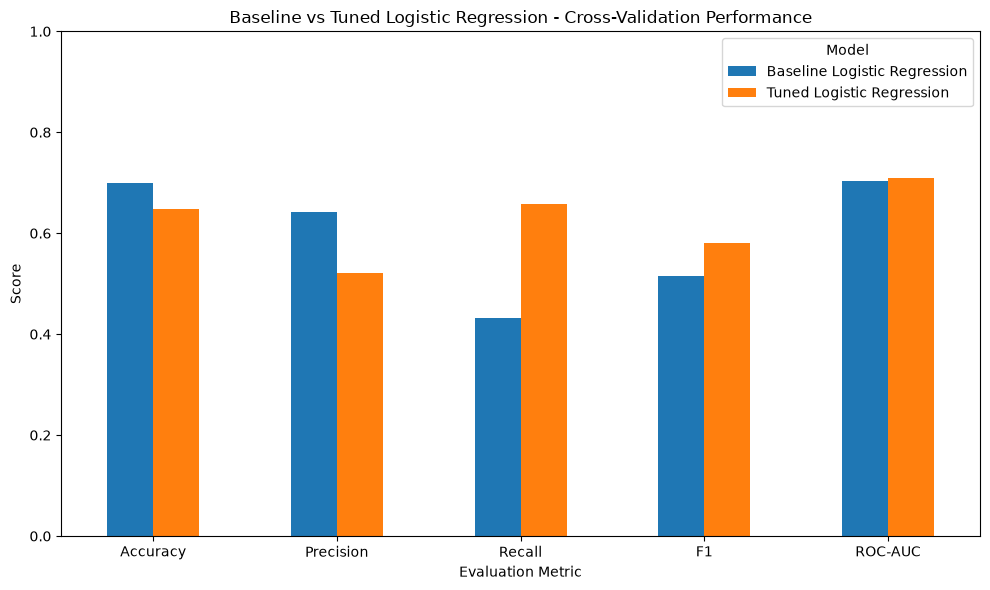

In [21]:
# Baseline Logistic Regression results (Section 4.1)
baseline_lr_metrics = cv_means(baseline_cv["Logistic Regression"])

# Tuned results
tuned_lr_metrics = cv_means(tuned_lr_cv_results)

lr_comparison = pd.DataFrame({
    "Baseline Logistic Regression": baseline_lr_metrics,
    "Tuned Logistic Regression": tuned_lr_metrics
})

display(lr_comparison.round(4))

lr_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Baseline vs Tuned Logistic Regression - Cross-Validation Performance"
)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### 7.7 Logistic Regression Optimization Observation

The best Logistic Regression configuration was:

- **`C` = 0.1** (fairly strong regularization)
- **`l1_ratio` = 1**, i.e. the **L1 (Lasso)** penalty
- **`class_weight` = 'balanced'**

Compared with the baseline model, cross-validation F1 increased from 0.516 to 0.581 (+0.065) and recall increased substantially, from 0.432 to 0.657. This was accompanied by a fall in precision (0.642 to 0.521) and accuracy (0.700 to 0.649).

**ROC-AUC barely changed (0.703 to 0.709).** ROC-AUC measures how well the model *ranks* leavers above stayers, independent of the decision threshold. Its stability shows that tuning did not make the model fundamentally better at telling the two groups apart. Instead, `class_weight='balanced'` mainly moved the decision boundary: the model now labels more employees as likely leavers. This catches more of the employees who really leave (higher recall) at the cost of more false alarms (lower precision). Because the gain in recall is larger than the loss in precision, F1 improves. The tuned accuracy (0.649) is only slightly above the 62.9% obtained by predicting "Stay" for everyone, which illustrates why accuracy alone is not used to select models.

**Regularization:** the combination of `C = 0.1` and the L1 penalty set 21 of the 41 coefficients to exactly zero, so the model performed its own feature selection. The four largest remaining coefficients are exactly the drivers identified in the EDA:

- `DoesOvertime` (+0.62): working overtime increases the predicted chance of leaving.
- `JobSatisfaction` (-0.44), `AppraisalRating` (-0.42) and `WorkLifeBalance` (-0.38): higher scores reduce the predicted chance of leaving.

All other coefficients are below 0.1 in size. This independently confirms the EDA findings and makes Logistic Regression a useful, interpretable benchmark.

**Generalization:** the training F1 (0.587) and validation F1 (0.581) differ by only 0.006, so the model does not overfit.

**Why Logistic Regression remains behind the tree-based models:** it can only combine features in a straight-line (additive) way. The tuned Decision Tree reaches an F1 of 0.687 using a handful of threshold rules, which suggests that attrition in this dataset follows threshold- and interaction-type patterns that a linear model cannot represent. Logistic Regression is therefore not selected as the final model, but it supports the final model by confirming which factors drive attrition.

## 8. K-Nearest Neighbors — Screening Check

KNN was the weakest baseline model in Stage 6 on every metric. Before deciding not to take it forward to full optimization, a quick screening check is carried out to make sure that this decision is based on evidence rather than on the default setting (K = 5) alone.

A grid search over the most influential KNN settings is performed on the scaled training data:

- `n_neighbors` (K) – how many neighbouring employees vote on the prediction. Small K follows local noise; large K gives smoother, more stable predictions.
- `weights` – `'uniform'` (every neighbour counts equally) or `'distance'` (closer neighbours count more).
- `p` – the distance measure: `1` = Manhattan distance, `2` = Euclidean distance.

If even the best KNN setting remains clearly below the tuned tree-based models, KNN is not taken forward.

In [22]:
knn_param_grid = {
    "n_neighbors": list(range(3, 52, 2)),   # odd K from 3 to 51 avoids tied votes
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn_grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True
)

knn_grid_search.fit(X_train_scaled, y_train)

print("Best KNN settings:", knn_grid_search.best_params_)
print("Best Cross-Validation F1:", round(knn_grid_search.best_score_, 4))

best_knn = knn_grid_search.best_estimator_

tuned_knn_cv_results = cross_validate(
    best_knn,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

knn_comparison = pd.DataFrame({
    "Baseline KNN (K=5)": cv_means(baseline_cv["KNN"]),
    "Best KNN from screening": cv_means(tuned_knn_cv_results)
})

display(knn_comparison.round(4))

Best KNN settings: {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Best Cross-Validation F1: 0.4362


,Baseline KNN (K=5),Best KNN from screening
Accuracy,0.6440,0.6285
Precision,0.5306,0.5001
Recall,0.3571,0.3875
F1,0.4266,0.4362
ROC-AUC,0.6149,0.5961


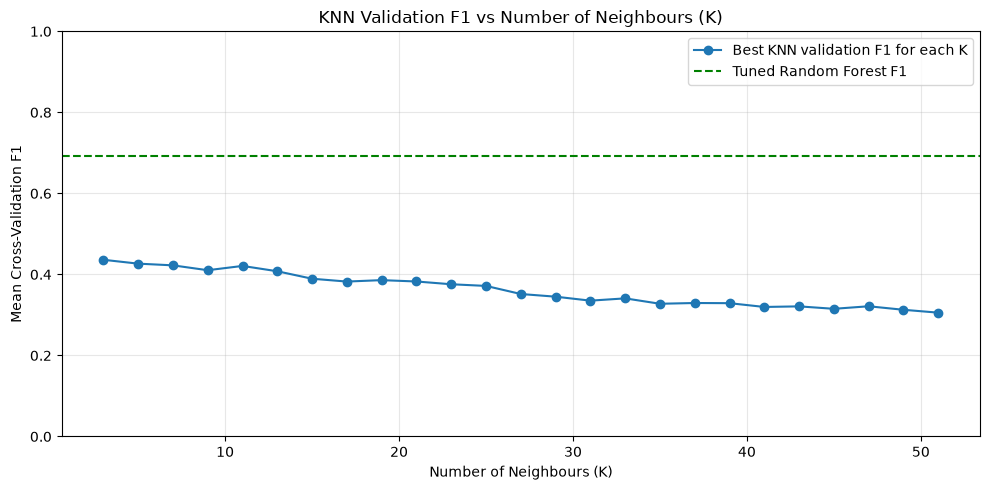

In [23]:
# How validation F1 changes with K (best weighting / distance setting for each K)
knn_results = pd.DataFrame(knn_grid_search.cv_results_)

f1_by_k = (
    knn_results
    .groupby("param_n_neighbors")["mean_test_score"]
    .max()
)

plt.figure(figsize=(10, 5))
plt.plot(f1_by_k.index, f1_by_k.values, marker="o", label="Best KNN validation F1 for each K")
plt.axhline(
    tuned_rf_cv_results["test_f1"].mean(),
    color="green",
    linestyle="--",
    label="Tuned Random Forest F1"
)
plt.title("KNN Validation F1 vs Number of Neighbours (K)")
plt.xlabel("Number of Neighbours (K)")
plt.ylabel("Mean Cross-Validation F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8.1 KNN Screening Observation

The screening grid search evaluated 100 KNN settings (50 values of K x 2 weighting methods x 2 distance measures).

The best setting was **K = 3, uniform weights, Euclidean distance**, with a cross-validation F1 of **0.436**, only slightly better than the default K = 5 (0.427). Its accuracy (0.629) and ROC-AUC (0.596) were actually lower than the baseline's.

The plot shows that F1 **decreases steadily as K increases** (from 0.436 at K = 3 to 0.306 at K = 51). With more neighbours voting, the majority class ("Stay") dominates more often, so fewer leavers are identified.

**Why KNN is not taken forward to full optimization or final selection:**

1. **Performance:** even the best KNN setting has an F1 about 0.26 lower than the tuned Random Forest (0.693) and is clearly below every other tuned model.
2. **Curse of dimensionality:** KNN treats all 41 scaled features as equally important when measuring distance, but only about four features carry real signal. The noise features dominate the distance, so an employee's "nearest neighbours" are not genuinely similar in the ways that matter for attrition. Tree-based models avoid this because they choose the most useful feature at each split.
3. **Practical suitability:** KNN gives no explanation of which factors drive a prediction, which HR users need, and it must store and search the whole training set for every prediction.

KNN is still included in the optimized-model comparison (Section 11) for reference.

## 9. Feature Selection Experiment

In addition to hyperparameter tuning, a feature selection experiment is performed to investigate whether reducing the number of input features can maintain or improve model performance.

Random Forest feature importance is used to rank the available features. A model that needs fewer inputs is simpler to explain and, importantly for the final system, requires HR users to enter fewer details.

In [24]:
# Extract feature importance from the tuned Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train_unscaled.columns,
    "Importance": tuned_random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
0,AppraisalRating,0.263597
1,JobSatisfaction,0.204349
2,DoesOvertime,0.202465
3,WorkLifeBalance,0.160193
4,PreviousCompanies,0.024347
5,JoiningYear,0.020287
6,MonthlySalary,0.019113
7,YearsWithCompany,0.018661
8,DistanceFromHome,0.014174
9,LeavesTaken,0.012753


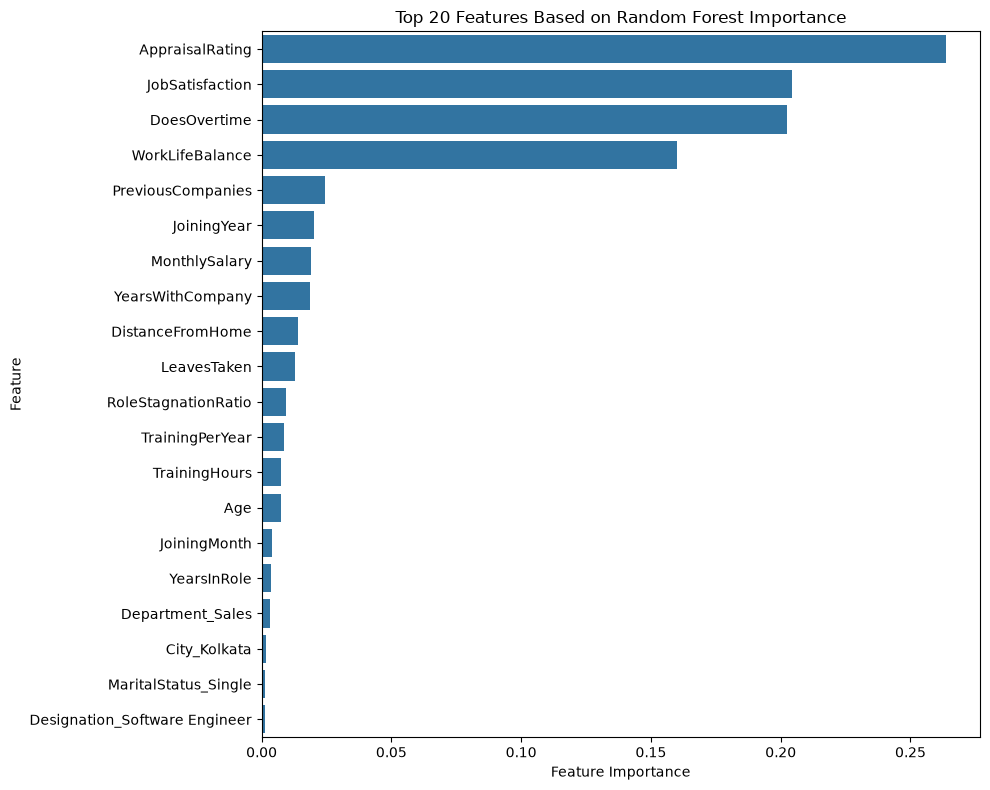

In [25]:
# Plot top 20 most important features
top_20_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_20_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features Based on Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 9.1 Evaluation of Different Feature Set Sizes (Selection Inside Cross-Validation)

The top 10, 15, 20, 25, 30 and all 41 features are evaluated with the tuned Random Forest settings.

**Avoiding selection bias:** if the feature ranking were calculated once on the whole training set and then evaluated with cross-validation on that same data, every validation fold would already have influenced which features were chosen, making the scores slightly optimistic. To prevent this, feature selection is placed **inside a pipeline**:

1. `SelectFromModel` fits a Random Forest on the training folds only and keeps the top *k* features by importance.
2. The tuned Random Forest is then trained on those *k* features and scored on the held-out fold.

The ranking is therefore recalculated in every fold without ever seeing that fold's validation data.

In [26]:
feature_counts = [10, 15, 20, 25, 30, X_train_unscaled.shape[1]]

feature_selection_results = []
feature_selection_cv = {}

for n_features in feature_counts:

    selection_pipeline = Pipeline([
        ("select", SelectFromModel(
            clone(tuned_random_forest),
            max_features=n_features,
            threshold=-np.inf          # keep exactly the top n_features by importance
        )),
        ("model", clone(tuned_random_forest))
    ])

    scores = cross_validate(
        selection_pipeline,
        X_train_unscaled,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    feature_selection_cv[n_features] = scores

    feature_selection_results.append({
        "Number of Features": n_features,
        **cv_means(scores),
        "F1 Std": scores["test_f1"].std()
    })

feature_selection_results = pd.DataFrame(feature_selection_results)

display(feature_selection_results.round(4))

,Number of Features,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Std
0,10,0.8020,0.8158,0.6024,0.6925,0.7640,0.0237
1,15,0.8035,0.8228,0.5997,0.6932,0.7603,0.0230
2,20,0.8038,0.8235,0.5997,0.6934,0.7575,0.0234
3,25,0.8038,0.8235,0.5997,0.6934,0.7576,0.0241
4,30,0.8038,0.8235,0.5997,0.6934,0.7576,0.0241
5,41,0.8038,0.8235,0.5997,0.6934,0.7580,0.0241


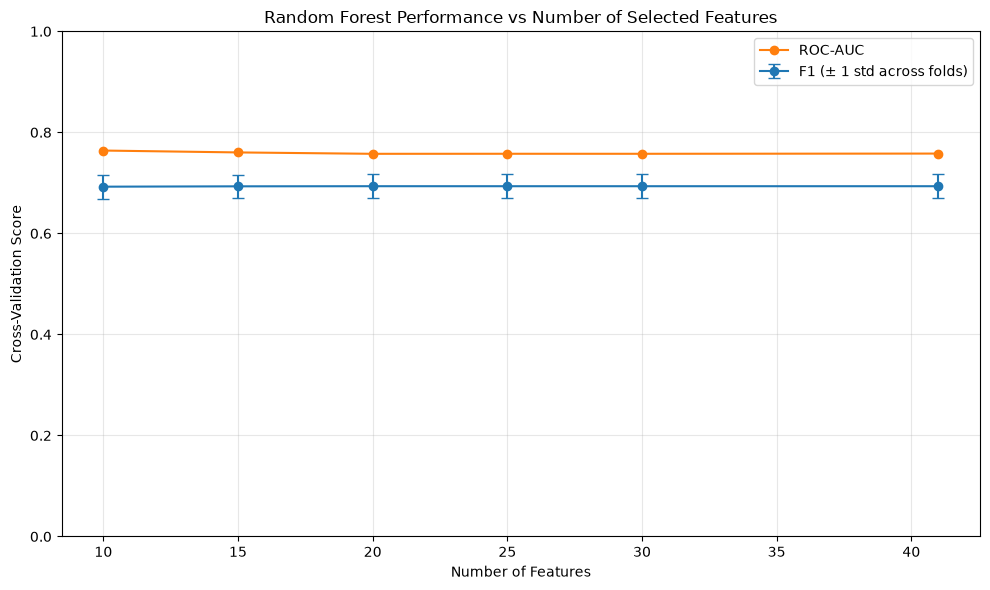

In [27]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    feature_selection_results["Number of Features"],
    feature_selection_results["F1"],
    yerr=feature_selection_results["F1 Std"],
    marker="o",
    capsize=4,
    label="F1 (± 1 std across folds)"
)

plt.plot(
    feature_selection_results["Number of Features"],
    feature_selection_results["ROC-AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.title("Random Forest Performance vs Number of Selected Features")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Selecting the Number of Features — One-Standard-Error Rule

Small differences in mean F1 between feature-set sizes may be due to random variation between folds rather than a real improvement. The **one-standard-error rule** is therefore used:

1. Find the feature-set size with the highest mean F1.
2. Calculate its standard error: fold standard deviation ÷ √5.
3. Choose the **smallest** feature set whose mean F1 is within one standard error of the best.

This chooses the simplest model that performs as well as the best one, within the uncertainty of the cross-validation estimate.

In [28]:
best_row = feature_selection_results.loc[feature_selection_results["F1"].idxmax()]
best_f1_standard_error = best_row["F1 Std"] / np.sqrt(cv_strategy.get_n_splits())
f1_threshold = best_row["F1"] - best_f1_standard_error

within_one_se = feature_selection_results[feature_selection_results["F1"] >= f1_threshold]
selected_feature_count = int(within_one_se["Number of Features"].min())

print(f"Highest mean F1            : {best_row['F1']:.4f} with {int(best_row['Number of Features'])} features")
print(f"Standard error of that F1  : {best_f1_standard_error:.4f}")
print(f"Threshold (best - 1 SE)    : {f1_threshold:.4f}")
print(f"Feature-set sizes within 1 SE: {within_one_se['Number of Features'].tolist()}")
print(f"\nSelected number of features: {selected_feature_count}")

Highest mean F1            : 0.6934 with 20 features
Standard error of that F1  : 0.0104
Threshold (best - 1 SE)    : 0.6830
Feature-set sizes within 1 SE: [10, 15, 20, 25, 30, 41]

Selected number of features: 10


In [29]:
# Final feature list: the top-ranked features from the tuned Random Forest
# trained on the complete training set (Section 9 ranking)
selected_features = feature_importance.head(
    selected_feature_count
)["Feature"].tolist()

print("Number of selected features:", len(selected_features))

print("\nSelected Features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

Number of selected features: 10

Selected Features:
1. AppraisalRating
2. JobSatisfaction
3. DoesOvertime
4. WorkLifeBalance
5. PreviousCompanies
6. JoiningYear
7. MonthlySalary
8. YearsWithCompany
9. DistanceFromHome
10. LeavesTaken


### 9.3 Feature-Selected Random Forest

The cross-validation results of the selected feature-set size are taken from the in-fold selection experiment above, so they are an unbiased estimate of how the feature-selected Random Forest performs.

In [30]:
selected_rf_cv_results = feature_selection_cv[selected_feature_count]

print(f"Feature-Selected Random Forest (top {selected_feature_count} features) - 5-Fold CV Results\n")

for metric in scoring_metrics:
    scores = selected_rf_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Feature-Selected Random Forest (top 10 features) - 5-Fold CV Results

Accuracy  : 0.8020 ± 0.0110
Precision : 0.8158 ± 0.0118
Recall    : 0.6024 ± 0.0345
F1        : 0.6925 ± 0.0237
Roc_auc   : 0.7640 ± 0.0140


### 9.4 Feature Selection Observation

The F1-score was almost identical for every feature-set size, ranging only from **0.6925 (10 features) to 0.6934 (20-41 features)**. This difference of less than 0.001 is about ten times smaller than the standard error of the cross-validation estimate (0.0104). All feature-set sizes are therefore statistically equivalent, and the one-standard-error rule selects the **smallest: 10 features**.

The top-10 Random Forest achieved a cross-validation F1 of 0.6925 and the **highest ROC-AUC of all feature-set sizes (0.764)**.

**Why so few features are enough:** the four strongest features (`AppraisalRating`, `JobSatisfaction`, `DoesOvertime`, `WorkLifeBalance`) account for about **83%** of the Random Forest's total feature importance, which matches the EDA finding that the signal is concentrated in these four variables. The one-hot encoded demographic columns (city, gender, department, designation, education, marital status) each contribute well under 1% of importance, consistent with the flat attrition rates seen across these groups in the EDA.

**Practical and ethical benefits of the 10-feature model:**

- HR users only need to enter 10 values in the final system instead of 41 encoded columns.
- The model does **not** use gender, marital status or city, which reduces the risk of unfair treatment of employees based on personal characteristics.

## 10. Robustness Check — Engagement Survey Features

The EDA (`01`, Section 13) flagged `JobSatisfaction` and `WorkLifeBalance` as a possible soft leakage risk: if these survey scores were collected at or near an employee's exit, they would partly reflect the decision to leave rather than predict it. The dataset contains no survey timestamp, so this cannot be confirmed or ruled out.

To measure how much the model depends on these two features, the tuned Random Forest is re-evaluated with them removed (using all other features). A large drop would mean the model's accuracy relies heavily on these features, which must then be collected from regular surveys, not exit interviews, when the system is used.

In [31]:
engagement_features = ["JobSatisfaction", "WorkLifeBalance"]

X_train_without_engagement = X_train_unscaled.drop(columns=engagement_features)

without_engagement_cv_results = cross_validate(
    clone(tuned_random_forest),
    X_train_without_engagement,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

engagement_comparison = pd.DataFrame({
    "Tuned RF - all features": cv_means(tuned_rf_cv_results),
    "Tuned RF - without engagement features": cv_means(without_engagement_cv_results)
})

engagement_comparison["Change"] = (
    engagement_comparison["Tuned RF - without engagement features"]
    - engagement_comparison["Tuned RF - all features"]
)

display(engagement_comparison.round(4))

,Tuned RF - all features,Tuned RF - without engagement features,Change
Accuracy,0.8038,0.5933,-0.2105
Precision,0.8235,0.4668,-0.3567
Recall,0.5997,0.6677,0.0680
F1,0.6934,0.5487,-0.1447
ROC-AUC,0.7580,0.6579,-0.1001


### 10.1 Robustness Check Observation

Removing `JobSatisfaction` and `WorkLifeBalance` caused a large drop in performance: F1 fell from 0.693 to 0.549, accuracy from 0.804 to 0.593, precision from 0.824 to 0.467 and ROC-AUC from 0.758 to 0.658.

Recall rose (0.600 to 0.668) only because, with much weaker information and balanced class weights, the model labels many more employees as likely leavers, most of them wrongly. Its accuracy (0.593) falls below the 62.9% that would be achieved by predicting "Stay" for everyone.

**Conclusion:** the model depends heavily on these two survey scores. They are **retained** because:

1. The EDA identified them as two of the strongest genuine drivers of attrition.
2. There is no evidence in the dataset that they were recorded at exit.

**Implication for deployment:** these scores must come from **regular engagement surveys** (for example quarterly or annual), collected while the employee is still working normally. If they were taken from exit interviews, they would partly reflect a decision already made, and real-world performance would be closer to the "without engagement features" column. This is documented as a limitation of the model.

## 11. Optimized Model Comparison

The optimized models are compared using the same stratified 5-fold cross-validation strategy. The best KNN setting from the screening check is included for reference.

F1-score is treated as the primary model-selection metric, while accuracy, precision, recall and ROC-AUC are also considered.

In [32]:
final_cv_comparison = pd.DataFrame([
    {"Model": "Tuned Logistic Regression", **cv_means(tuned_lr_cv_results)},
    {"Model": "Best KNN (screening)", **cv_means(tuned_knn_cv_results)},
    {"Model": "Tuned Decision Tree", **cv_means(tuned_dt_cv_results)},
    {"Model": "Tuned Random Forest", **cv_means(tuned_rf_cv_results)},
    {"Model": f"Random Forest - Top {selected_feature_count} Features", **cv_means(selected_rf_cv_results)}
])

final_cv_comparison["F1 Std"] = [
    tuned_lr_cv_results["test_f1"].std(),
    tuned_knn_cv_results["test_f1"].std(),
    tuned_dt_cv_results["test_f1"].std(),
    tuned_rf_cv_results["test_f1"].std(),
    selected_rf_cv_results["test_f1"].std()
]

final_cv_comparison = final_cv_comparison.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(final_cv_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Std
0,Tuned Random Forest,0.8038,0.8235,0.5997,0.6934,0.7580,0.0241
1,Random Forest - Top 10 Features,0.8020,0.8158,0.6024,0.6925,0.7640,0.0237
2,Tuned Decision Tree,0.8010,0.8228,0.5909,0.6874,0.7552,0.0218
3,Tuned Logistic Regression,0.6488,0.5208,0.6570,0.5808,0.7090,0.0201
4,Best KNN (screening),0.6285,0.5001,0.3875,0.4362,0.5961,0.0108


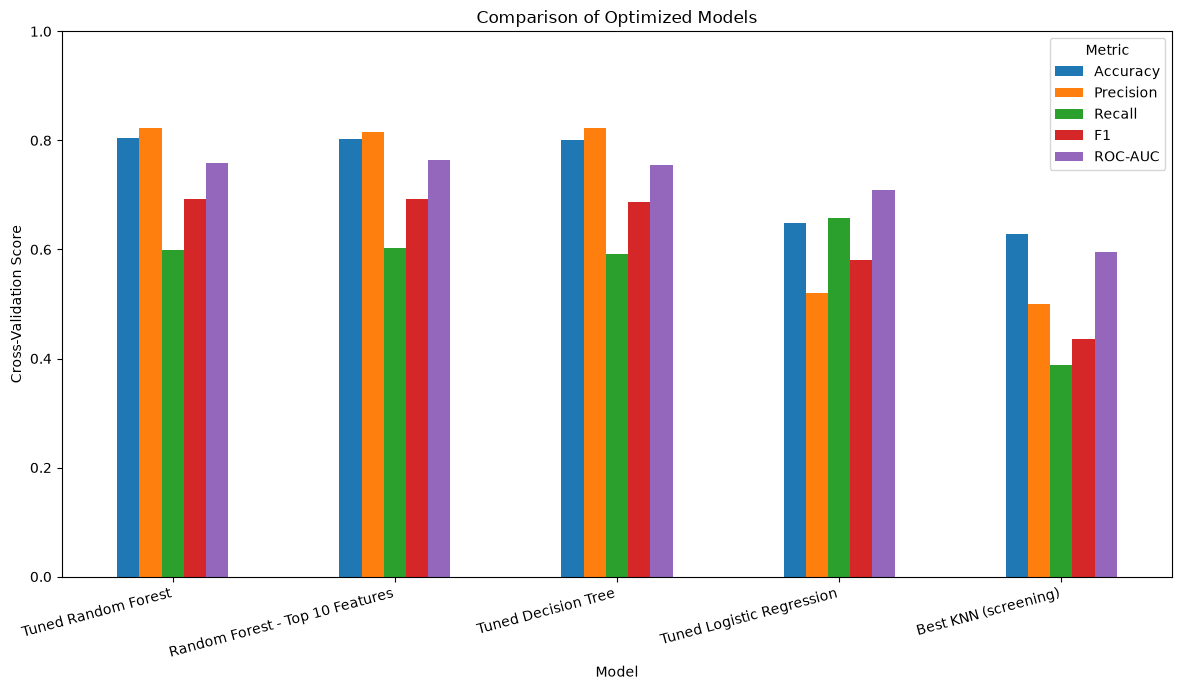

In [33]:
comparison_plot = final_cv_comparison.set_index("Model").drop(columns="F1 Std")

comparison_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Comparison of Optimized Models")
plt.ylabel("Cross-Validation Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 11.1 Baseline vs Tuned — All Models

The table below summarises the effect of optimization on every algorithm, using mean cross-validation F1 and ROC-AUC.

In [34]:
tuned_cv_by_model = {
    "Logistic Regression": tuned_lr_cv_results,
    "KNN": tuned_knn_cv_results,
    "Decision Tree": tuned_dt_cv_results,
    "Random Forest": tuned_rf_cv_results
}

baseline_vs_tuned = pd.DataFrame({
    name: {
        "Baseline F1": baseline_cv[name]["test_f1"].mean(),
        "Tuned F1": tuned_cv_by_model[name]["test_f1"].mean(),
        "Baseline ROC-AUC": baseline_cv[name]["test_roc_auc"].mean(),
        "Tuned ROC-AUC": tuned_cv_by_model[name]["test_roc_auc"].mean()
    }
    for name in baseline_cv
}).T

baseline_vs_tuned["F1 Change"] = baseline_vs_tuned["Tuned F1"] - baseline_vs_tuned["Baseline F1"]

display(baseline_vs_tuned.round(4))

,Baseline F1,Tuned F1,Baseline ROC-AUC,Tuned ROC-AUC,F1 Change
Logistic Regression,0.5161,0.5808,0.7032,0.7090,0.0647
KNN,0.4266,0.4362,0.6149,0.5961,0.0095
Decision Tree,0.5577,0.6874,0.6466,0.7552,0.1297
Random Forest,0.6790,0.6934,0.7612,0.7580,0.0144


### 11.2 Optimized Model Comparison Observation

Ranked by cross-validation F1-score:

1. **Tuned Random Forest (all 41 features):** F1 0.6934, ROC-AUC 0.758
2. **Random Forest, top 10 features:** F1 0.6925, ROC-AUC **0.764** (highest)
3. **Tuned Decision Tree:** F1 0.6874, ROC-AUC 0.755
4. **Tuned Logistic Regression:** F1 0.5808, ROC-AUC 0.709
5. **Best KNN:** F1 0.4362, ROC-AUC 0.596

The top three tree-based models are within **0.006 F1** of each other, much less than their fold-to-fold standard deviation (about 0.022-0.024). Their F1 performance is therefore statistically equivalent. They are all clearly ahead of Logistic Regression (about 0.11 lower F1) and KNN (about 0.26 lower).

**Effect of tuning (Section 11.1):**

- **Decision Tree** gained the most (+0.130 F1), because the baseline tree was badly overfitted and limiting its depth fixed this.
- **Logistic Regression** gained +0.065 F1, mostly through class weighting, which traded precision for recall.
- **Random Forest** gained +0.014 F1. The baseline was already strong; the main benefit was removing overfitting.
- **KNN** gained only +0.010 F1, confirming that its weakness comes from the algorithm itself rather than its settings.

Tuning improved the F1-score of every model but did not change the overall ranking of the algorithm families: tree-based models are the most suitable for this problem.

## 12. Final Model Evaluation

The **tuned Random Forest using the top 10 features** is selected as the final model candidate. Its cross-validation F1 (0.6925) is within one standard error of the best model, it has the highest cross-validation ROC-AUC (0.764), and it needs only 10 inputs. The full justification is given in Section 14.

The final model is trained on the complete training dataset using the 10 selected features and evaluated **once** on the previously untouched test dataset. The test set was not used during hyperparameter tuning, feature selection or model selection, so it provides an independent estimate of final model performance.

In [35]:
# Prepare selected training and testing features
X_train_final = X_train_unscaled[selected_features]
X_test_final = X_test_unscaled[selected_features]

print("Final Training Shape:", X_train_final.shape)
print("Final Testing Shape :", X_test_final.shape)

# Train a fresh copy of the tuned Random Forest on the selected features
final_model = clone(tuned_random_forest)

final_model.fit(
    X_train_final,
    y_train
)

print("\nFinal model trained successfully.")
print("Final model settings:", random_forest_random_search.best_params_)

Final Training Shape: (4000, 10)
Final Testing Shape : (1000, 10)



Final model trained successfully.
Final model settings: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 5, 'class_weight': 'balanced'}


### 12.1 Final Test-Set Performance

The trained final model is evaluated on the untouched test dataset using accuracy, precision, recall, F1-score and ROC-AUC.

These metrics provide the final assessment of how well the selected model generalizes to unseen employee records.

In [36]:
# Predictions
y_test_pred = final_model.predict(X_test_final)

# Probability of class 1
y_test_prob = final_model.predict_proba(X_test_final)[:, 1]

# Calculate metrics
final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)
final_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Final Model - Test Set Performance\n")

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1        : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Stay (0)", "Left (1)"]
    )
)

Final Model - Test Set Performance

Accuracy  : 0.7870
Precision : 0.7904
Recall    : 0.5795
F1        : 0.6687
ROC-AUC   : 0.7433

Classification Report:

              precision    recall  f1-score   support

    Stay (0)       0.79      0.91      0.84       629
    Left (1)       0.79      0.58      0.67       371

    accuracy                           0.79      1000
   macro avg       0.79      0.74      0.76      1000
weighted avg       0.79      0.79      0.78      1000



### 12.2 Confusion Matrix

The confusion matrix is used to examine the types of predictions made by the final model. It shows correctly and incorrectly classified employees for both the Stay and Left classes.

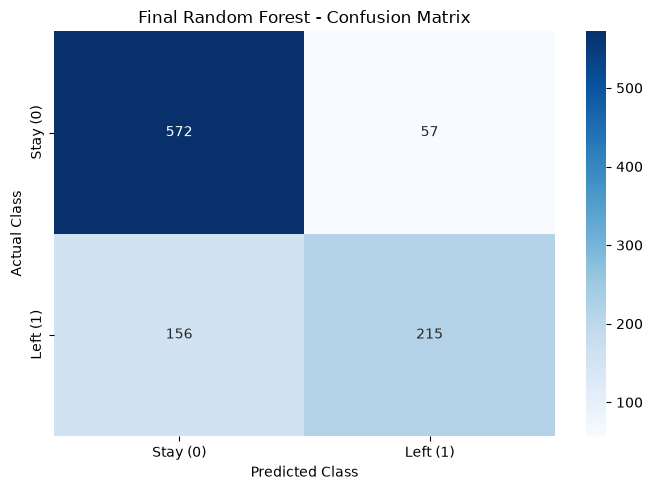

In [37]:
final_cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay (0)", "Left (1)"],
    yticklabels=["Stay (0)", "Left (1)"]
)

plt.title("Final Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

#### Confusion Matrix Observation

The final model produced:

- **572** true negatives: employees who stayed, correctly predicted to stay.
- **215** true positives: employees who left, correctly flagged as at risk.
- **57** false positives: employees who stayed but were flagged as at risk.
- **156** false negatives: employees who left but were not flagged.

Of the 272 employees the model flags as at risk, **215 (79%) actually left**, so when the system raises an alert, HR can trust it about four times out of five. Of the 371 employees who actually left, the model identifies **215 (58%)**. The 156 missed leavers are the main limitation (see Section 15).

Compared with the baseline Random Forest from Stage 6 (211 leavers caught, 55 false alarms, using all 41 features), the final model catches 4 more leavers for 2 more false alarms while using only 10 features.

### 12.3 ROC Curve

The ROC curve evaluates the ability of the final model to distinguish between employees who stay and employees who leave across different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall discrimination ability of the model.

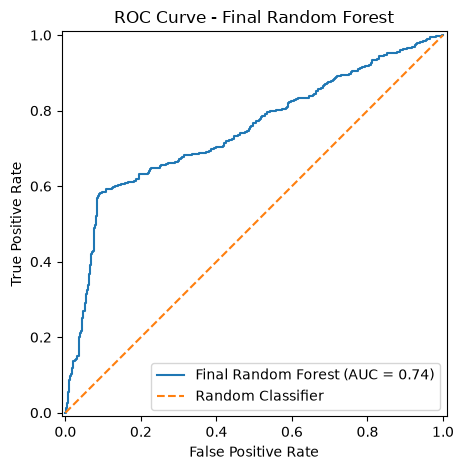

In [38]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob,
    name="Final Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Final Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Cross-Validation and Final Test Performance

Comparing the cross-validation performance of the selected model with its test performance shows whether the model generalizes to previously unseen data.

In [39]:
# Cross-validation performance of selected model
cv_final_metrics = {
    "Accuracy": selected_rf_cv_results["test_accuracy"].mean(),
    "Precision": selected_rf_cv_results["test_precision"].mean(),
    "Recall": selected_rf_cv_results["test_recall"].mean(),
    "F1": selected_rf_cv_results["test_f1"].mean(),
    "ROC-AUC": selected_rf_cv_results["test_roc_auc"].mean()
}

# Final test performance
test_final_metrics = {
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "ROC-AUC": final_roc_auc
}

generalization_comparison = pd.DataFrame({
    "Cross-Validation": cv_final_metrics,
    "Final Test Set": test_final_metrics
})

display(generalization_comparison.round(4))

,Cross-Validation,Final Test Set
Accuracy,0.8020,0.7870
Precision,0.8158,0.7904
Recall,0.6024,0.5795
F1,0.6925,0.6687
ROC-AUC,0.7640,0.7433


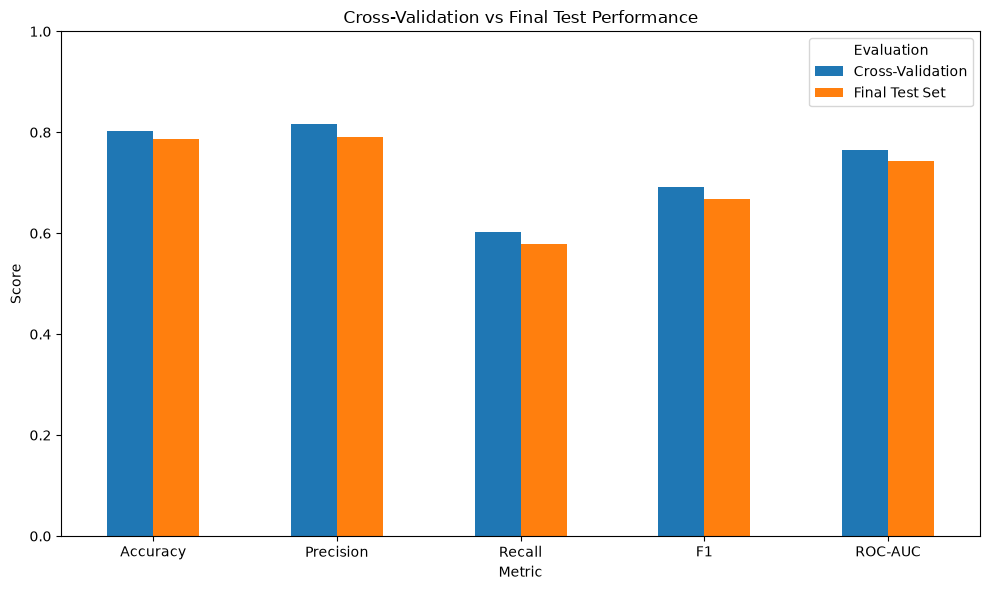

In [40]:
generalization_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cross-Validation vs Final Test Performance")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation")
plt.tight_layout()
plt.show()

## 14. Final Model Selection

**Selected model:** tuned **Random Forest** using the **top 10 features**.

| Setting | Value |
|---|---|
| Number of trees | 200 |
| Maximum depth | 5 |
| Minimum samples split / leaf | 2 / 8 |
| Max features | None (all features at each split) |
| Class weight | balanced |
| Input features | AppraisalRating, JobSatisfaction, DoesOvertime, WorkLifeBalance, PreviousCompanies, JoiningYear, MonthlySalary, YearsWithCompany, DistanceFromHome, LeavesTaken |

**Why F1-score is the primary selection metric:** both types of error are costly for the organisation. A missed leaver (false negative) means losing an employee without any chance to intervene; a false alarm (false positive) wastes retention effort and budget on an employee who was going to stay. F1 balances precision and recall for the attrition class, and it is not distorted by the 62.9% / 37.1% class imbalance the way accuracy is.

**Justification:**

1. **Performance:** cross-validation F1 of 0.6925, within 0.001 of the best model (tuned Random Forest with all features, 0.6934) and well within one standard error (0.0104). It has the **highest cross-validation ROC-AUC (0.764)** of all models.
2. **Clearly better than the other algorithm families:** Logistic Regression (F1 0.581) and KNN (F1 0.436) are far behind.
3. **Compared with the tuned Decision Tree** (F1 0.687, ROC-AUC 0.755): the F1-scores are similar, but the Random Forest ranks employees better (higher ROC-AUC). Because it averages 200 trees, it also gives smooth, fine-grained risk probabilities (1,000 different probability values on the 1,000 test employees), whereas a depth-5 tree can output at most 32 different values. This matters because HR will use the predicted probability to prioritise employees by risk. An ensemble is also less sensitive to small changes in the data than a single tree.
4. **Generalization:** the training-validation F1 gap is only 0.007, and test performance is close to cross-validation performance (F1 0.669 vs 0.693, accuracy 0.787 vs 0.802, ROC-AUC 0.743 vs 0.764). The small drop on the test set is expected and does not indicate overfitting.
5. **Practicality and fairness:** it needs only 10 inputs from HR and does not use gender, marital status or city.

Therefore, the tuned Random Forest with the top 10 features is retained as the final model and is saved for the prediction system.

## 15. Important Observations and Limitations

**Key observations:**

1. Random Forest gave the strongest overall performance among the baseline models, and remained the best model family after tuning.
2. Controlling model complexity was the most important optimization: limiting tree depth removed the severe overfitting of the baseline Decision Tree (+0.130 F1) and of the baseline Random Forest (training-validation gap reduced from 0.321 to 0.007).
3. For Logistic Regression, `class_weight='balanced'` increased recall from 0.432 to 0.657 and F1 from 0.516 to 0.581, but ROC-AUC barely changed. The tuning moved the decision threshold rather than improving the model's ability to separate leavers from stayers.
4. KNN remained the weakest model even after screening 100 settings, because its distance calculation gives equal weight to the many uninformative features.
5. Three different models (L1 Logistic Regression coefficients, Random Forest importance and the EDA) agree that **appraisal rating, job satisfaction, overtime and work-life balance** are the main drivers of attrition. Salary, age, commute distance and demographic factors have little effect in this dataset.
6. Feature selection showed that 10 features perform as well as all 41.
7. The final model achieved an F1-score of 0.669 and ROC-AUC of 0.743 on the untouched test set, close to its cross-validation performance.

**Limitations:**

- **Recall:** the final model identifies 58% of employees who leave; 156 of 371 leavers in the test set were missed. If HR values catching leavers more than avoiding false alarms, the decision threshold (currently 0.5) could be lowered in the prediction system, which raises recall at the cost of precision.
- **Dependence on survey data:** performance relies heavily on `JobSatisfaction` and `WorkLifeBalance` (Section 10). These must come from regular surveys, not exit interviews.
- **Synthetic data:** the EDA showed signs that the dataset is synthetically generated (uniform distributions, no missing values, flat attrition across most groups). Results should be validated on real company data before the model is used for real decisions.

## 16. Saving the Final Model

The selected Random Forest model and its selected feature list are saved so that the same trained model and feature configuration can later be used by the backend (Stage 9) without retraining. The feature list also fixes the **column order** the model expects.

In [41]:
# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save final trained model
joblib.dump(
    final_model,
    "../models/final_random_forest_model.pkl"
)

# Save selected feature names
joblib.dump(
    selected_features,
    "../models/selected_features.pkl"
)

print("Final model saved successfully.")
print("Selected feature list saved successfully.")
print("Number of selected features:", len(selected_features))

Final model saved successfully.
Selected feature list saved successfully.
Number of selected features: 10
